# Retail Sales Data – Exploratory Data Analysis

## Internship Project – Data Analytics

### Objective

Perform Exploratory Data Analysis (EDA) on retail sales data to identify
sales patterns, customer behaviour trends, product performance, and
actionable business insights.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print(os.getcwd())

C:\Users\ACER\OneDrive\Desktop


In [3]:
from pathlib import Path

matches = list(Path.home().rglob("retail_sales_dataset.csv"))

print("Files found:")
for file in matches:
    print(file)

Files found:
C:\Users\ACER\OneDrive\Desktop\archive (3)\retail_sales_dataset.csv


In [4]:
df = pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\archive (3)\retail_sales_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [7]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [8]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date column converted to datetime successfully!")
print(df['Date'].dtype)

Date column converted to datetime successfully!
datetime64[ns]


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics

Descriptive statistics were calculated for all numerical variables in the
retail sales dataset. Mean and median provide measures of central tendency,
while mode identifies the most frequently occurring value. Standard deviation
shows the amount of variation in each numerical variable.

These statistics provide an initial understanding of customer age, quantity
purchased, price per unit, and total sales amount.

In [14]:
print("Total Revenue:", df['Total Amount'].sum())
print("Average Transaction Value:", df['Total Amount'].mean())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Customer Age:", df['Age'].mean())

Total Revenue: 456000
Average Transaction Value: 456.0
Total Quantity Sold: 2514
Average Customer Age: 41.392


## Monthly Sales Trend

Monthly sales are analyzed to identify changes in revenue over time.
A line chart is used to observe increasing, decreasing, or fluctuating
sales patterns across the months.

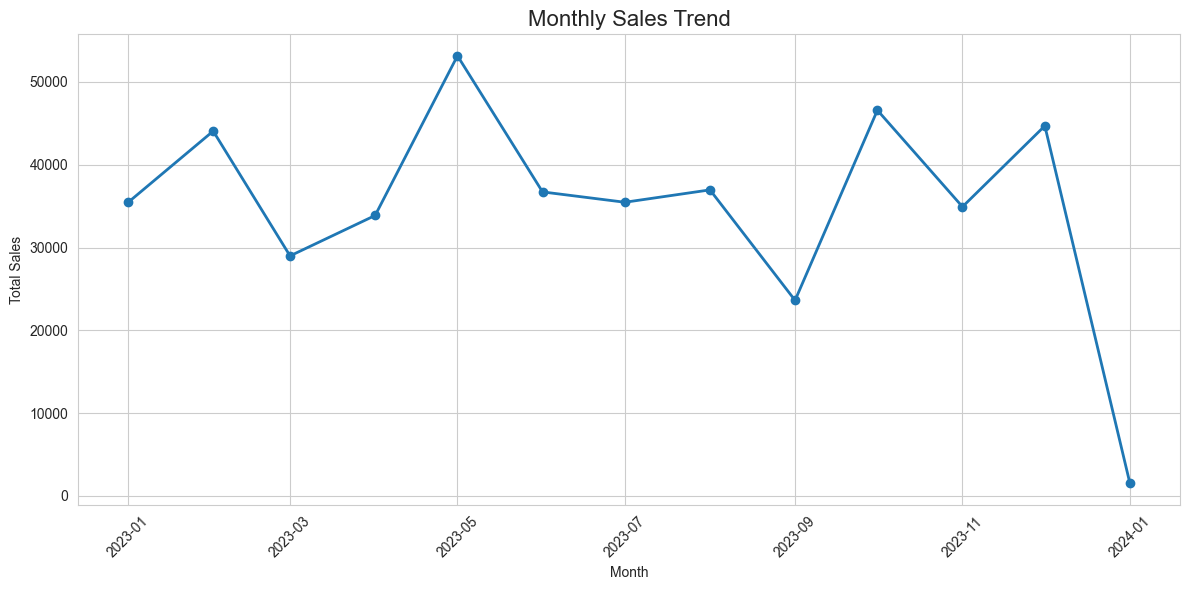

In [15]:
# Calculate monthly sales
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# Convert period to timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot monthly sales
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Highest sales month:", highest_month.strftime("%B %Y"))
print("Highest sales:", highest_sales)

print("Lowest sales month:", lowest_month.strftime("%B %Y"))
print("Lowest sales:", lowest_sales)

Highest sales month: May 2023
Highest sales: 53150
Lowest sales month: January 2024
Lowest sales: 1530


### Observation

The monthly sales analysis shows variations in revenue across the
observed period. The highest-performing month generated the greatest
sales revenue, while the lowest-performing month recorded the minimum
revenue. These fluctuations indicate that sales performance varies over
time and may be influenced by customer purchasing patterns, product
demand, or seasonal factors.

## Quarterly Sales Trend

Quarterly sales analysis groups the transactions into three-month periods.
This helps identify broader sales patterns and compare business performance
across quarters.

Quarterly Sales:
Date
2023-01-01    108500
2023-04-01    123735
2023-07-01     96045
2023-10-01    126190
2024-01-01      1530
Freq: QS-OCT, Name: Total Amount, dtype: int64


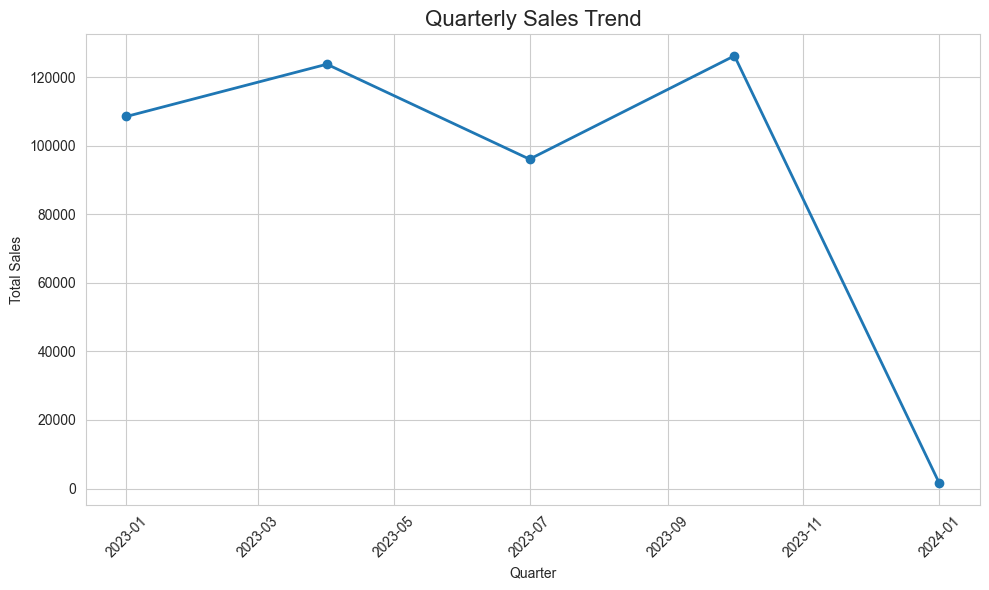

In [17]:
# Calculate quarterly sales
quarterly_sales = df.groupby(
    df['Date'].dt.to_period('Q')
)['Total Amount'].sum()

# Convert period to timestamp
quarterly_sales.index = quarterly_sales.index.to_timestamp()

# Display quarterly sales
print("Quarterly Sales:")
print(quarterly_sales)

# Plot quarterly sales
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o',
    linewidth=2
)

plt.title('Quarterly Sales Trend', fontsize=16)
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales analysis provides a broader view of revenue performance
over time. Comparing the quarters helps identify periods of stronger and
weaker sales performance and provides useful information for planning
inventory, marketing campaigns, and sales strategies.

## Customer Demographics Analysis

Customer demographics are analyzed using age groups and gender distribution.
Understanding these characteristics helps identify the major customer
segments and supports more targeted marketing decisions.

In [18]:
# Create customer age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count customers in each age group
age_group_counts = df['Age Group'].value_counts().sort_index()

print(age_group_counts)

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64


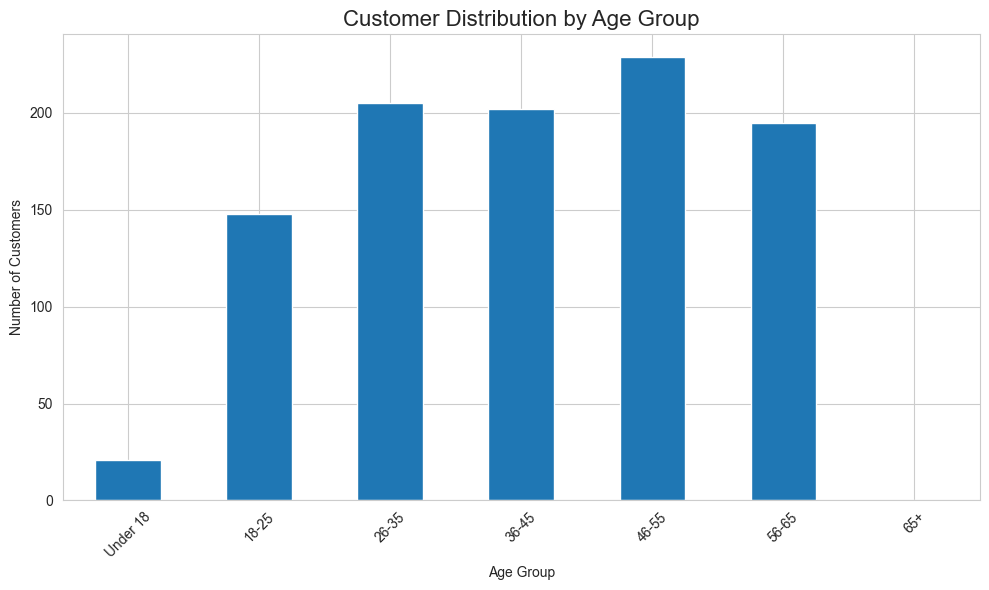

In [19]:
plt.figure(figsize=(10, 6))

age_group_counts.plot(
    kind='bar'
)

plt.title('Customer Distribution by Age Group', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The age-group analysis shows how customers are distributed across different
age ranges. Identifying the most represented age group helps the business
understand its primary customer demographic and develop age-appropriate
marketing campaigns and product strategies.

In [20]:
gender_counts = df['Gender'].value_counts()

print("Gender Distribution:")
print(gender_counts)

Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64


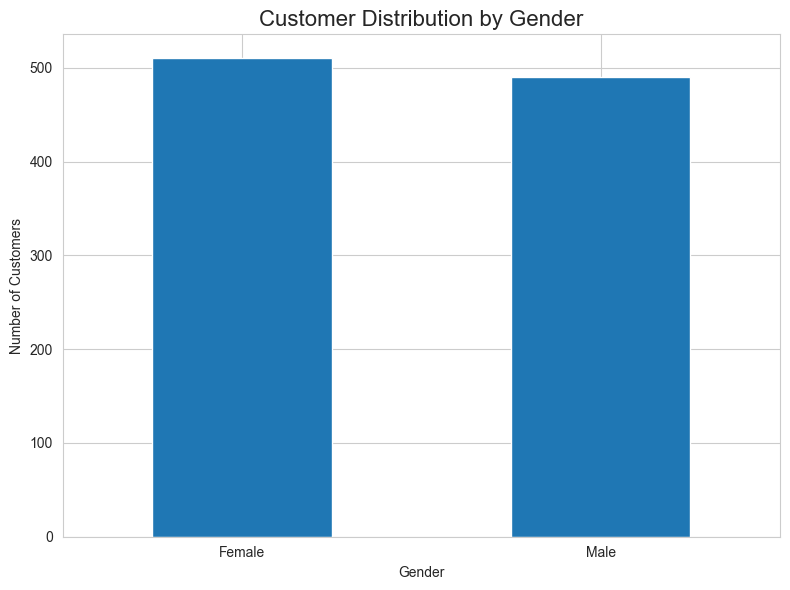

In [21]:
plt.figure(figsize=(8, 6))

gender_counts.plot(
    kind='bar'
)

plt.title('Customer Distribution by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The gender distribution shows the number of customers belonging to each
gender category. This information can help the business understand whether
its customer base is relatively balanced or concentrated toward a particular
gender, supporting more targeted promotional strategies.

## Product Analysis

Product performance is analyzed using product categories. Since the dataset
contains product categories rather than individual product names, the
analysis focuses on category-level sales quantity and revenue.

In [22]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Quantity Sold by Product Category:")
print(category_quantity)

Quantity Sold by Product Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


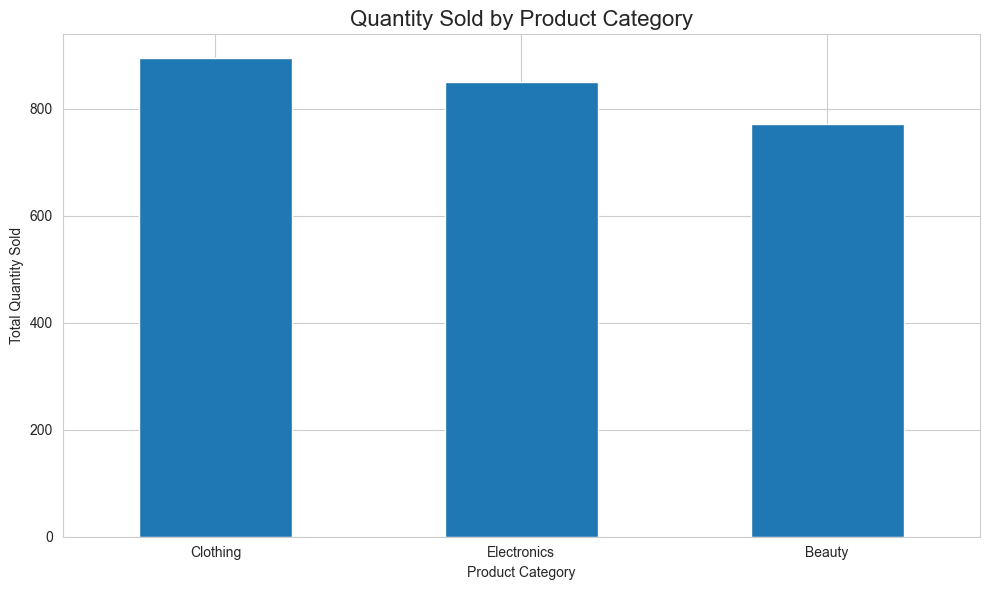

In [23]:
plt.figure(figsize=(10, 6))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category', fontsize=16)
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Product Category:")
print(category_revenue)

Revenue by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


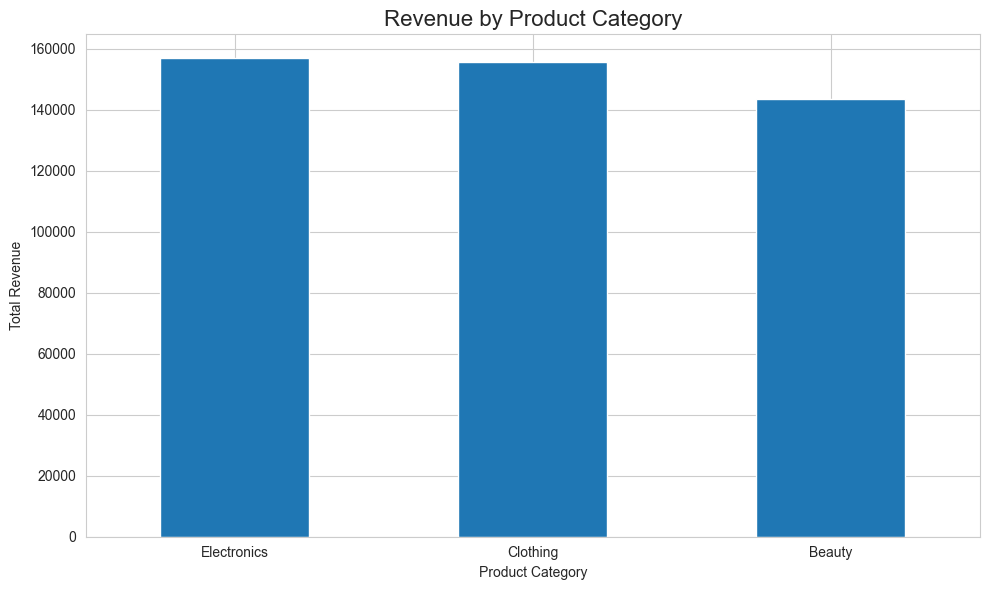

In [25]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category', fontsize=16)
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
top_quantity_category = category_quantity.idxmax()
top_quantity_value = category_quantity.max()

top_revenue_category = category_revenue.idxmax()
top_revenue_value = category_revenue.max()

print("Highest-selling category:", top_quantity_category)
print("Quantity sold:", top_quantity_value)

print("\nHighest-revenue category:", top_revenue_category)
print("Revenue:", top_revenue_value)

Highest-selling category: Clothing
Quantity sold: 894

Highest-revenue category: Electronics
Revenue: 156905


### Observation

The product category analysis highlights differences in both sales volume
and revenue contribution. The highest-selling category contributes the
largest quantity of units sold, while the highest-revenue category generates
the greatest sales value. These results can help the business prioritize
inventory, promotions, and category-specific marketing strategies.

In [27]:
# Select numerical columns for correlation analysis
numeric_data = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


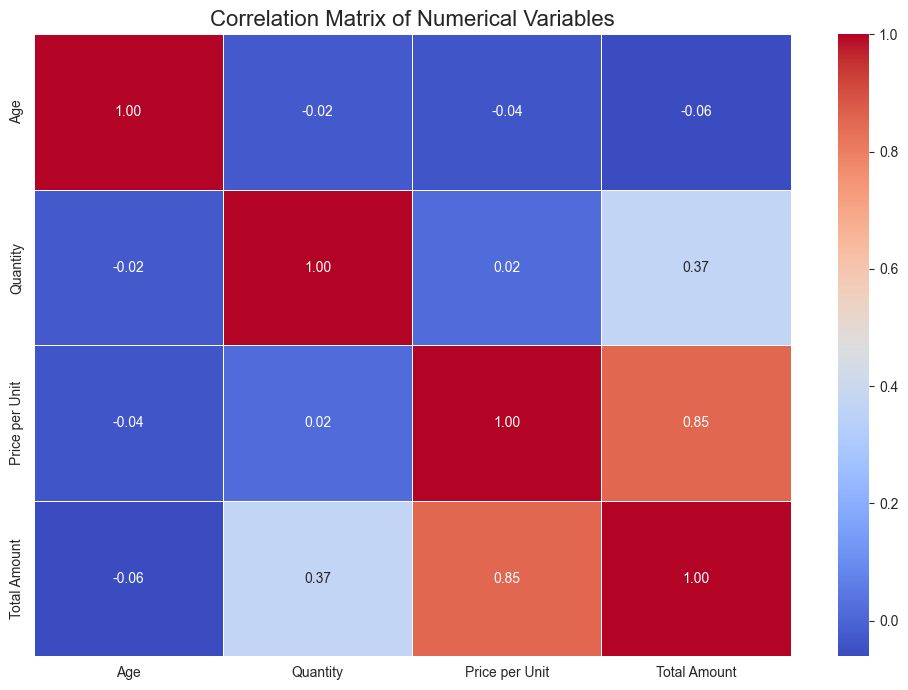

In [28]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships
between the numerical variables. Positive values indicate that two variables
tend to increase together, while negative values indicate an inverse
relationship. The strength of each relationship can be assessed using the
correlation coefficient.

## Additional Visualization – Sales Distribution by Gender and Product Category

This visualization compares revenue across gender and product categories.
It helps identify whether certain product categories generate more revenue
from a particular customer gender.

In [29]:
gender_category_sales = df.groupby(
    ['Gender', 'Product Category']
)['Total Amount'].sum().unstack()

print("Revenue by Gender and Product Category:")
display(gender_category_sales)

Revenue by Gender and Product Category:


Product Category,Beauty,Clothing,Electronics
Gender,,,
Female,74830,81275,76735
Male,68685,74305,80170


<Figure size 1000x600 with 0 Axes>

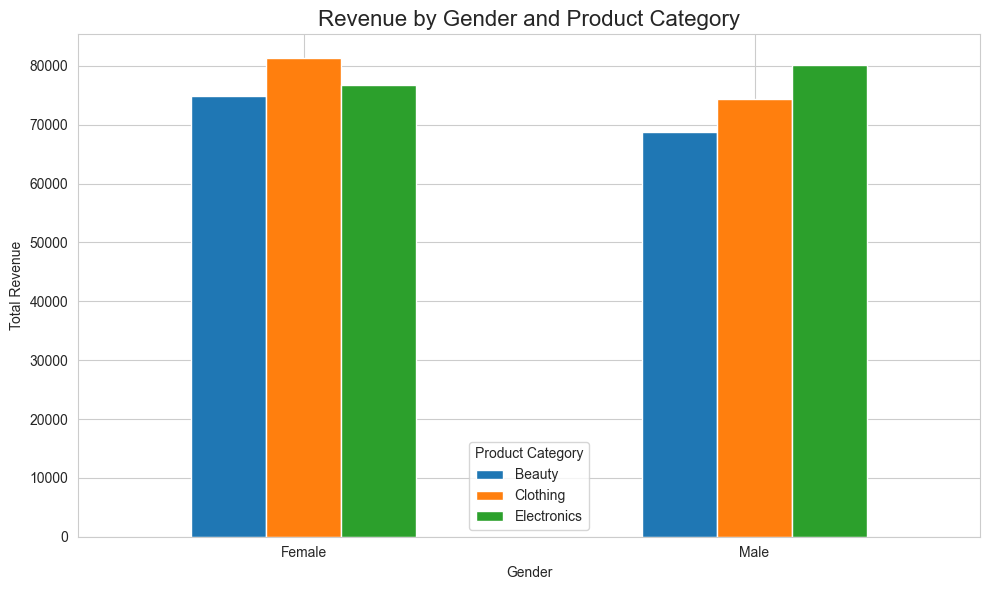

In [30]:
plt.figure(figsize=(10, 6))

gender_category_sales.plot(kind='bar', figsize=(10, 6))

plt.title('Revenue by Gender and Product Category', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

### Observation

The visualization compares revenue generated by different genders across
product categories. It helps identify category preferences and differences
in revenue contribution between customer groups. These insights can support
more targeted marketing campaigns and category-specific promotional
strategies.

## Conclusion and Business Recommendations

The exploratory data analysis provided useful insights into the retail
sales dataset, including sales trends, customer demographics, product
category performance, and relationships between numerical variables.

The analysis of monthly and quarterly sales helps identify changes in
business performance over time. Customer age and gender analysis provides
an understanding of the customer base, while category-level analysis shows
which product categories contribute most to sales quantity and revenue.

### Actionable Business Recommendations

1. **Optimize inventory**
   Focus inventory planning on high-performing product categories to reduce
   stock shortages and maintain product availability.

2. **Use targeted marketing**
   Use customer age-group and gender distribution insights to design
   targeted promotional campaigns for the major customer segments.

3. **Plan promotions around sales trends**
   Use monthly and quarterly sales patterns to schedule promotions,
   discounts, and marketing campaigns during weaker sales periods while
   maintaining sufficient inventory during stronger periods.

### Dataset Limitation

The dataset contains product categories rather than individual product
names. Therefore, the product-performance analysis was conducted at the
product-category level instead of identifying the top 10 individual
products.

In [31]:
print("EDA Task 1 completed successfully!")
print("Rows analyzed:", len(df))
print("Columns analyzed:", len(df.columns))
print("Total Revenue:", df['Total Amount'].sum())
print("Total Quantity Sold:", df['Quantity'].sum())

EDA Task 1 completed successfully!
Rows analyzed: 1000
Columns analyzed: 10
Total Revenue: 456000
Total Quantity Sold: 2514


# Task 2 – Customer Segmentation Analysis

## Objective

The objective of this task is to segment customers based on their purchasing
behaviour using RFM analysis and K-Means clustering.

RFM stands for:

- **Recency** – How recently a customer made a purchase.
- **Frequency** – How often a customer makes purchases.
- **Monetary** – How much a customer has spent.

K-Means clustering is used to group customers with similar purchasing
behaviour into meaningful customer segments.

In [32]:
customer_summary = df.groupby('Customer ID').agg({
    'Date': 'max',
    'Transaction ID': 'count',
    'Total Amount': 'sum'
})

customer_summary.columns = [
    'Last Purchase Date',
    'Purchase Frequency',
    'Monetary Value'
]

customer_summary.head()

,Last Purchase Date,Purchase Frequency,Monetary Value
Customer ID,,,
CUST001,2023-11-24,1,150
CUST002,2023-02-27,1,1000
CUST003,2023-01-13,1,30
CUST004,2023-05-21,1,500
CUST005,2023-05-06,1,100


In [33]:
reference_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'Transaction ID': 'count',
    'Total Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,39,1,150
CUST002,309,1,1000
CUST003,354,1,30
CUST004,226,1,500
CUST005,241,1,100


## RFM Distribution

The RFM metrics are examined using descriptive statistics to understand
customer purchasing behaviour before applying clustering.

In [34]:
rfm.describe()

,Recency,Frequency,Monetary
count,1000.000000,1000.0,1000.000000
mean,182.982000,1.0,456.000000
std,105.276773,0.0,559.997632
min,1.000000,1.0,25.000000
25%,90.000000,1.0,60.000000
50%,186.500000,1.0,135.000000
75%,269.000000,1.0,900.000000
max,366.000000,1.0,2000.000000


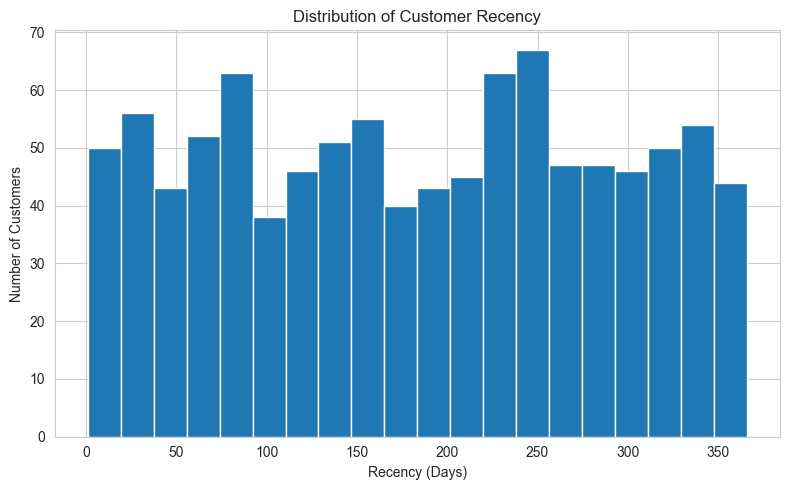

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Recency'], bins=20)
plt.title('Distribution of Customer Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

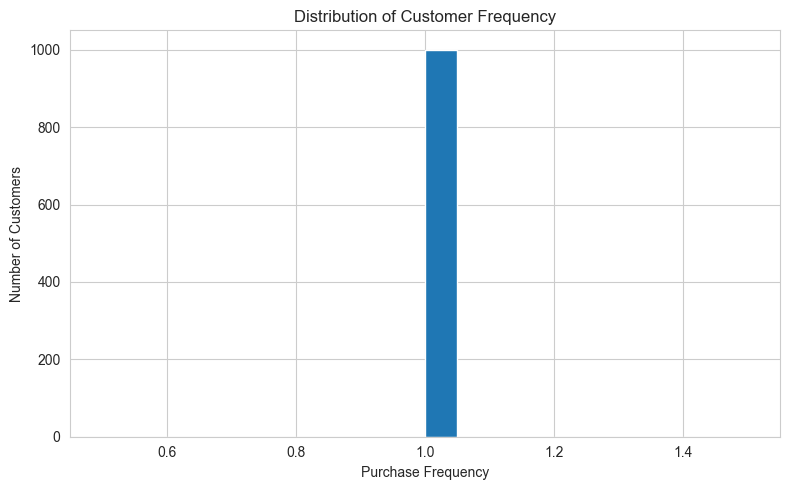

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Frequency'], bins=20)
plt.title('Distribution of Customer Frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

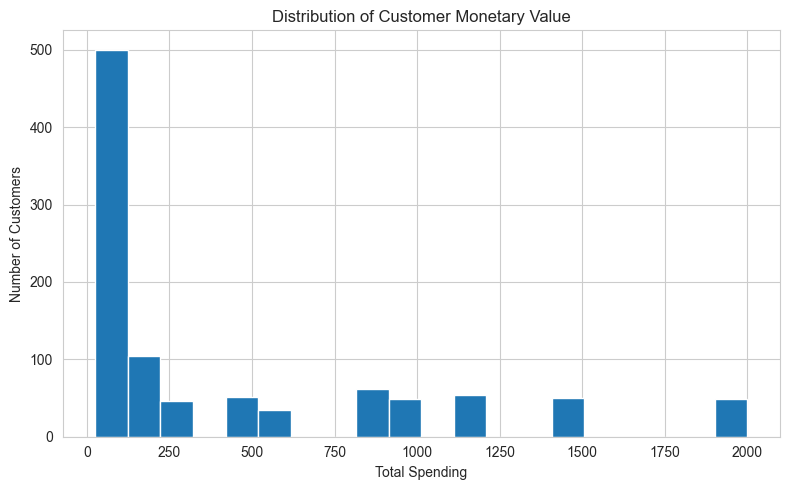

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Monetary'], bins=20)
plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Data Standardization

The RFM variables have different scales and units. StandardScaler is used
to standardize the variables so that each RFM metric contributes
appropriately to the K-Means clustering process.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,-1.368336,0.0,-0.546704
CUST002,1.197615,0.0,0.971919
CUST003,1.625274,0.0,-0.761098
CUST004,0.408823,0.0,0.078611
CUST005,0.551375,0.0,-0.636035


## Elbow Method

The Elbow Method is used to determine an appropriate number of clusters for
K-Means clustering. The Within-Cluster Sum of Squares (WCSS) is calculated
for different numbers of clusters. The point where the decrease in WCSS
starts to slow down indicates a suitable number of clusters.

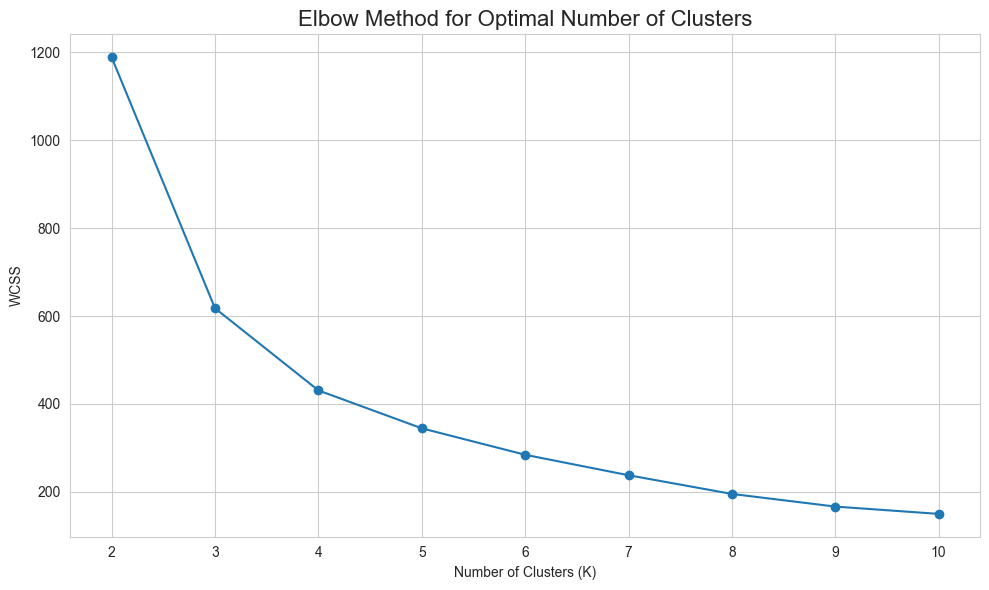

In [39]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=16)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

### Observation

The WCSS decreases as the number of clusters increases. Based on the Elbow
Method and the structure of the customer data, four clusters are selected
for customer segmentation.

## K-Means Customer Segmentation

K-Means clustering is applied with four clusters to group customers based on
their Recency, Frequency, and Monetary values.

In [40]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
CUST001,39,1,150,1
CUST002,309,1,1000,0
CUST003,354,1,30,2
CUST004,226,1,500,2
CUST005,241,1,100,2


In [41]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    140
1    370
2    366
3    124
Name: count, dtype: int64


## Cluster Profiling

The average Recency, Frequency, and Monetary values of each cluster are
calculated to understand the purchasing behaviour of different customer
segments.

In [42]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,270.52,1.0,1283.57
1,92.12,1.0,159.77
2,274.57,1.0,148.32
3,84.94,1.0,1313.71


In [43]:
cluster_profile['Customer Count'] = rfm.groupby('Cluster').size()

cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,270.52,1.0,1283.57,140
1,92.12,1.0,159.77,370
2,274.57,1.0,148.32,366
3,84.94,1.0,1313.71,124


## Customer Distribution by Cluster

The number of customers in each cluster is visualized to compare the size
of the identified customer segments.

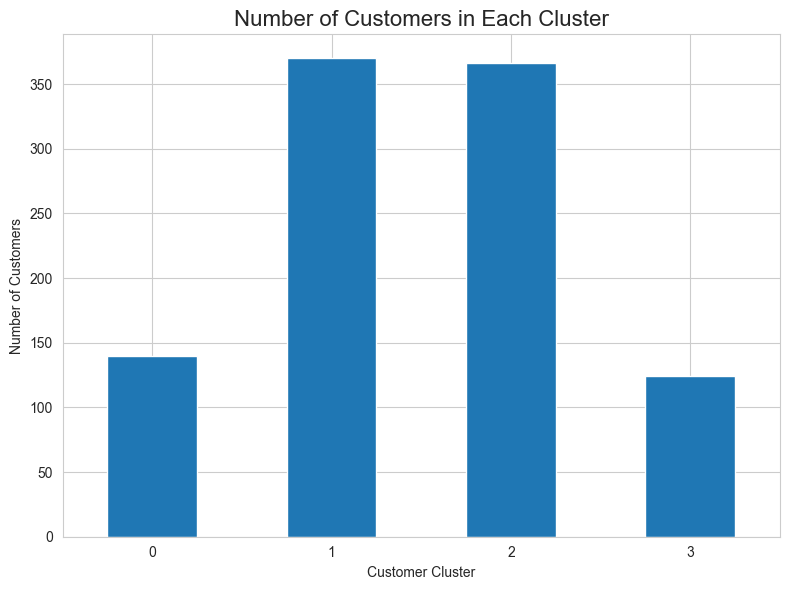

In [44]:
plt.figure(figsize=(8, 6))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Cluster', fontsize=16)
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,270.52,1.0,1283.57,140
1,92.12,1.0,159.77,370
2,274.57,1.0,148.32,366
3,84.94,1.0,1313.71,124


## Customer Segmentation Visualization

Scatter plots are used to visualize the relationship between RFM metrics
and the identified customer clusters. This helps illustrate how customers
with different purchasing behaviours are grouped.

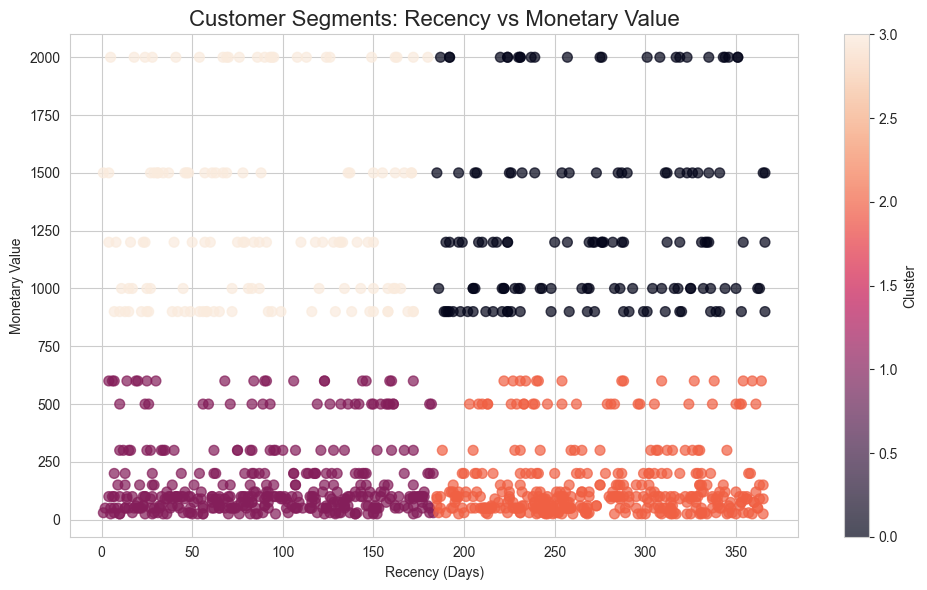

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    s=50,
    alpha=0.7
)

plt.title('Customer Segments: Recency vs Monetary Value', fontsize=16)
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

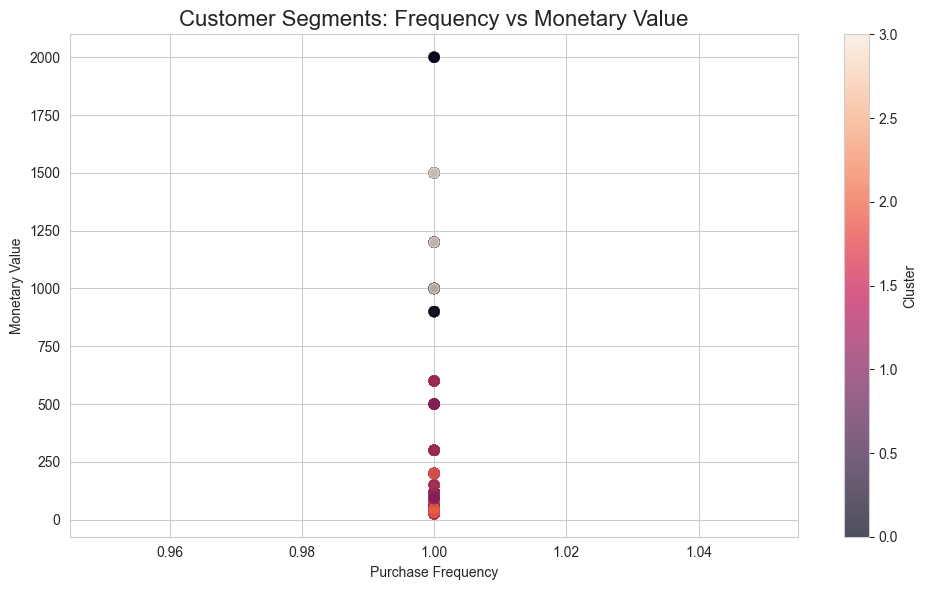

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    s=50,
    alpha=0.7
)

plt.title('Customer Segments: Frequency vs Monetary Value', fontsize=16)
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

### Observation

The scatter plots show how customers are distributed across the four
K-Means clusters based on their RFM characteristics. Customers within the
same cluster have relatively similar purchasing behaviour, while customers
in different clusters show differences in recency, purchase frequency,
and monetary value.

## Marketing Strategies for Customer Segments

The identified customer segments can be used to develop targeted marketing
strategies.

### Segment 1 – High-Value Customers
Provide loyalty rewards, exclusive offers, premium products, and early access
to new products to retain valuable customers.

### Segment 2 – Regular Customers
Use personalized promotions, product recommendations, and loyalty programs
to encourage repeat purchases.

### Segment 3 – At-Risk Customers
Use special discounts, personalized messages, and limited-time offers to
encourage customers to return.

### Segment 4 – Low-Engagement Customers
Use introductory offers, re-engagement campaigns, and low-cost promotions
to increase customer activity.

## Conclusion

RFM analysis and K-Means clustering were successfully used to segment
customers according to their purchasing behaviour. Four customer clusters
were identified based on Recency, Frequency, and Monetary characteristics.

Customer segmentation helps the business understand different customer
groups and develop targeted marketing strategies. By focusing on customer
retention, personalized promotions, and re-engagement campaigns, the
business can improve customer relationships and potentially increase
sales.

# Task 3 – Data Cleaning

## Objective

The objective of this task is to identify and handle data quality issues
in the retail sales dataset. The cleaning process includes checking missing
values, duplicate records, incorrect data types, formatting issues, and
potential outliers.

## Data Quality Assessment

A data quality assessment is performed to identify missing values,
duplicate records, incorrect data types, and other potential issues
before further analysis.

In [48]:
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique Values': df.nunique().values
})

quality_report

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Transaction ID,int64,0,0.0,1000
1,Date,datetime64[ns],0,0.0,345
2,Customer ID,object,0,0.0,1000
3,Gender,object,0,0.0,2
4,Age,int64,0,0.0,47
5,Product Category,object,0,0.0,3
6,Quantity,int64,0,0.0,4
7,Price per Unit,int64,0,0.0,5
8,Total Amount,int64,0,0.0,18
9,Age Group,category,0,0.0,6


## Duplicate Records

Duplicate records are checked because repeated transactions can affect
sales calculations and customer analysis.

In [49]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Missing Values

Missing values are checked for every column. If missing values are found,
an appropriate treatment strategy should be selected based on the nature
of the column and the amount of missing data.

In [50]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Age Group           0
dtype: int64


### Missing Data Handling Strategy

The dataset was checked for missing values in every column. No missing
values were found in any column, so no imputation or row deletion was
required.

The following strategy would be appropriate if missing values were present:

- Transaction ID: Do not impute; investigate or remove invalid records.
- Date: Do not arbitrarily fill dates; investigate the source data.
- Customer ID: Do not impute; investigate missing customer identifiers.
- Gender: Use the mode only if the missing values are limited.
- Age: Use the median if necessary because it is less affected by extreme values.
- Product Category: Use the mode if only a small number of values are missing.
- Quantity: Use the median if appropriate.
- Price per Unit: Use the median if appropriate.
- Total Amount: Recalculate from Quantity × Price per Unit when possible.

Since this dataset contains no missing values, none of these treatments
were applied.

## Data Type Validation

The data types of all columns are examined to ensure that each variable is
stored in an appropriate format for analysis.

In [51]:
print("Final data types:")
print(cleaned_df.dtypes)

Final data types:


NameError: name 'cleaned_df' is not defined

## Formatting Validation

Text fields are checked for unnecessary leading or trailing spaces and
inconsistent formatting. Standardizing text values helps maintain data
consistency.

In [ ]:
text_columns = df.select_dtypes(include='object').columns

for column in text_columns:
    print(f"\n{column}:")
    print(df[column].unique())

In [ ]:
for column in text_columns:
    df[column] = df[column].str.strip()

print("Text formatting standardized successfully.")

## Outlier Detection

Potential outliers are identified in numerical variables using the
Interquartile Range (IQR) method. The IQR method identifies observations
that fall below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

In [ ]:
numerical_columns = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

outlier_report = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_report.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[column].dropna())
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

## Data Cleaning and Validation

The dataset is cleaned by standardizing text formatting, validating data
types, checking missing values and duplicates, and reviewing potential
outliers. Legitimate extreme values are retained because they may represent
valid retail transactions rather than data-entry errors.

In [ ]:
# Create a cleaned copy of the dataset
cleaned_df = df.copy()

# Remove duplicate records
cleaned_df = cleaned_df.drop_duplicates()

# Remove leading and trailing spaces from text columns
text_columns = cleaned_df.select_dtypes(include='object').columns

for column in text_columns:
    cleaned_df[column] = cleaned_df[column].str.strip()

# Ensure Date has the correct data type
cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])

print("Data cleaning completed.")
print("Original rows:", len(df))
print("Cleaned rows:", len(cleaned_df))

## Before and After Cleaning Comparison

The following comparison summarizes the dataset before and after the
cleaning process.

In [ ]:
comparison = pd.DataFrame({
    'Measure': [
        'Number of Rows',
        'Number of Columns',
        'Missing Values',
        'Duplicate Rows'
    ],
    'Before Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    'After Cleaning': [
        cleaned_df.shape[0],
        cleaned_df.shape[1],
        cleaned_df.isnull().sum().sum(),
        cleaned_df.duplicated().sum()
    ]
})

comparison

In [ ]:
cleaned_df.to_csv('retail_sales_cleaned.csv', index=False)

print("Cleaned dataset saved successfully as retail_sales_cleaned.csv")

In [ ]:
print("Final dataset information:")
cleaned_df.info()

## Task 3 Conclusion

The retail sales dataset was successfully assessed and cleaned. Missing
values and duplicate records were checked, text formatting was standardized,
the Date column was validated as a datetime variable, and numerical
variables were examined for potential outliers using the IQR method.

Potential outliers were reviewed rather than automatically removed because
extreme values may represent legitimate retail transactions. The cleaned
dataset was saved as `retail_sales_cleaned.csv` for future analysis.

In [ ]:
import os

print(os.path.exists('retail_sales_cleaned.csv'))

In [ ]:
cluster_profile

## Customer Segment Profiles

The four clusters show differences mainly in Recency and Monetary value.
Purchase Frequency is 1.0 for all clusters, indicating that frequency does
not provide meaningful separation between the customer groups in this
dataset.

### Cluster 0 – High-Spending Inactive Customers

These customers have a relatively high Recency value, meaning their purchases
were made longer ago. However, their average Monetary value is high.

**Marketing Action:** Use re-engagement campaigns, personalized discounts,
and special offers to encourage these high-value customers to return.

### Cluster 1 – Recent Low-Spending Customers

These customers have relatively low Recency values, indicating more recent
purchases, but their average Monetary value is comparatively low.

**Marketing Action:** Use cross-selling, product recommendations, and
limited-time offers to increase their spending.

### Cluster 2 – Low-Spending Inactive Customers

These customers have high Recency values and relatively low Monetary value.
They represent customers who have not purchased recently and have generated
lower spending.

**Marketing Action:** Use low-cost reactivation campaigns and introductory
offers to encourage another purchase.

### Cluster 3 – Recent High-Spending Customers

These customers have relatively low Recency values and the highest Monetary
value among the four clusters. They represent an important high-value
customer segment.

**Marketing Action:** Focus on customer retention through loyalty rewards,
personalized recommendations, and exclusive offers.

In [ ]:
cluster_profile[['Recency', 'Monetary']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Recency and Monetary Value by Customer Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cluster Profile Observation

Clusters 0 and 2 have higher Recency values, indicating less recent
purchases. Clusters 1 and 3 have lower Recency values, indicating more
recent purchases. Clusters 0 and 3 have substantially higher Monetary
values, making them the most valuable segments in terms of average spending.

Since Frequency is 1.0 across all clusters, purchase frequency does not
meaningfully distinguish the segments in this dataset.

In [ ]:
print("Final data types:")
print(cleaned_df.dtypes)

In [ ]:
print("FINAL DATASET VERIFICATION")
print("---------------------------")
print("Rows and Columns:", cleaned_df.shape)
print("Missing Values:", cleaned_df.isnull().sum().sum())
print("Duplicate Rows:", cleaned_df.duplicated().sum())
print("\nFinal Data Types:")
print(cleaned_df.dtypes)